In [1]:
import sys
sys.path.append('../')

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd
import optuna
from copy import deepcopy
from torch.utils.data import DataLoader
from src.mypackage.torch_dataset import EnergyDataset
from src.mypackage.trainer import Trainer
from src.mypackage.rnn_models import RNNModel

In [2]:
# ========== データ読み込みとデータセット準備 ==========
df = pd.read_csv("../data/raw/PJME_hourly.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

SEQ_LEN = 168
PRED_LEN = 24
SHIFT = 24
BATCH_SIZE = 32

# ========== データセット作成 ==========
dataset = EnergyDataset(df, seq_len=SEQ_LEN, shift=SHIFT, pred_len=PRED_LEN, mode="re-train")
retrain_dataset = deepcopy(dataset)
train_dataset = deepcopy(dataset)
train_dataset.mode_switch("train")
valid_dataset = deepcopy(dataset)
valid_dataset.mode_switch("val")
test_dataset = deepcopy(dataset)
test_dataset.mode_switch("test")

# DataLoader作成
retrain_loader = DataLoader(retrain_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Whole dataset size: {len(retrain_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Input features: {train_dataset[0][0].shape[1]}")


Dataset shape: (145366, 2)
Columns: ['Datetime', 'PJME_MW']
Whole dataset size: 5654
Train dataset size: 5289
Val dataset size: 358
Test dataset size: 358
Input features: 19


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== ハイパーパラメータ設定 ==========
# 固定
NUM_EPOCHS = 50
INPUT_SIZE = train_dataset[0][0].shape[1]
EARLY_STOPPING_PATIENCE = 5
OUTPUT_SIZE = PRED_LEN

def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    hidden_size = 2 ** trial.suggest_int("hidden_size", 4, 9)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    model_type = trial.suggest_categorical("model_type", ["RNN", "LSTM", "GRU"])

    model = RNNModel(input_size=INPUT_SIZE, 
                     hidden_size=hidden_size, 
                     num_layers=num_layers, 
                     output_size=OUTPUT_SIZE, 
                     dropout=dropout,
                     rnn_type=model_type).to(device)

    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        checkpoint_dir="../models/rnn_checkpoints"
    )
    history = trainer.train(num_epochs=NUM_EPOCHS, verbose=False)
    best_iteration = trainer.early_stopping.best_iteration
    trial.set_user_attr("best_iteration", best_iteration)
    trial.set_user_attr("trainer", trainer)
    return min(history['val_loss'])

Using device: cpu


In [4]:
# パラメータ探索の実行
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=20)
print(study.best_params)

[I 2026-07-10 14:19:37,171] A new study created in memory with name: no-name-f5c94be5-7462-4886-a8ab-57d2ae3f9537


Validation loss decreased (inf --> 0.143679). Saving model...
Validation loss decreased (0.143679 --> 0.138667). Saving model...
EarlyStopping counter: 1 out of 5
EarlyStopping counter: 2 out of 5
Validation loss decreased (0.138667 --> 0.116229). Saving model...
Validation loss decreased (0.116229 --> 0.110563). Saving model...
EarlyStopping counter: 1 out of 5
Validation loss decreased (0.110563 --> 0.104848). Saving model...
EarlyStopping counter: 1 out of 5
EarlyStopping counter: 2 out of 5
EarlyStopping counter: 3 out of 5
EarlyStopping counter: 4 out of 5
EarlyStopping counter: 5 out of 5
Checkpoint loaded from ..\models\rnn_checkpoints\best_model.pt


[I 2026-07-10 15:01:04,744] Trial 0 finished with value: 0.10484765004366636 and parameters: {'learning_rate': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'hidden_size': 8, 'num_layers': 3, 'dropout': 0.1624074561769746, 'model_type': 'GRU'}. Best is trial 0 with value: 0.10484765004366636.


Validation loss decreased (inf --> 0.514089). Saving model...
Validation loss decreased (0.514089 --> 0.348449). Saving model...
Validation loss decreased (0.348449 --> 0.280157). Saving model...
Validation loss decreased (0.280157 --> 0.262270). Saving model...
Validation loss decreased (0.262270 --> 0.229689). Saving model...
Validation loss decreased (0.229689 --> 0.185582). Saving model...
Validation loss decreased (0.185582 --> 0.171473). Saving model...
Validation loss decreased (0.171473 --> 0.157851). Saving model...
Validation loss decreased (0.157851 --> 0.157757). Saving model...
Validation loss decreased (0.157757 --> 0.149983). Saving model...
Validation loss decreased (0.149983 --> 0.139887). Saving model...
EarlyStopping counter: 1 out of 5
EarlyStopping counter: 2 out of 5
Validation loss decreased (0.139887 --> 0.129039). Saving model...
EarlyStopping counter: 1 out of 5
EarlyStopping counter: 2 out of 5
EarlyStopping counter: 3 out of 5
EarlyStopping counter: 4 out of

[I 2026-07-10 15:09:59,857] Trial 1 finished with value: 0.12903850649793944 and parameters: {'learning_rate': 0.0006358358856676254, 'weight_decay': 0.000133112160807369, 'hidden_size': 4, 'num_layers': 4, 'dropout': 0.4329770563201687, 'model_type': 'RNN'}. Best is trial 0 with value: 0.10484765004366636.


EarlyStopping counter: 5 out of 5
Checkpoint loaded from ..\models\rnn_checkpoints\best_model.pt
Validation loss decreased (inf --> 0.426458). Saving model...
Validation loss decreased (0.426458 --> 0.258323). Saving model...
Validation loss decreased (0.258323 --> 0.218681). Saving model...
Validation loss decreased (0.218681 --> 0.192188). Saving model...
Validation loss decreased (0.192188 --> 0.166728). Saving model...
Validation loss decreased (0.166728 --> 0.152248). Saving model...
Validation loss decreased (0.152248 --> 0.150685). Saving model...
Validation loss decreased (0.150685 --> 0.148594). Saving model...


[W 2026-07-10 15:17:12,027] Trial 2 failed with parameters: {'learning_rate': 8.17949947521167e-05, 'weight_decay': 3.752055855124284e-05, 'hidden_size': 6, 'num_layers': 2, 'dropout': 0.34474115788895177, 'model_type': 'GRU'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\sh204\py_env\ds_env\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\sh204\AppData\Local\Temp\ipykernel_5564\936869292.py", line 37, in objective
    history = trainer.train(num_epochs=NUM_EPOCHS, verbose=False)
  File "c:\Users\sh204\portfolio\hourly_energy_consumption\notebooks\..\src\mypackage\trainer.py", line 179, in train
    train_loss, train_mae, train_rmse = self._train_epoch()
                                        ~~~~~~~~~~~~~~~~~^^
  File "c:\Users\sh204\portfolio\hourly_energy_consumption\notebooks\..\src\mypackage\trainer.py", line 128, in _train_epoch
    loss.backward()
 

KeyboardInterrupt: 

In [ ]:
# モデルの再学習
model = RNNModel(input_size=INPUT_SIZE,
                 hidden_size=study.best_params["hidden_size"], 
                 num_layers=study.best_params["num_layers"], 
                 output_size=OUTPUT_SIZE, 
                 dropout=study.best_params["dropout"],
                 rnn_type=study.best_params["model_type"]).to(device)

trainer = Trainer(model=model,
                  train_loader=retrain_loader,
                  test_loader=test_loader,
                  device=device,
                  learning_rate=study.best_params["learning_rate"],
                  weight_decay=study.best_params["weight_decay"],
                  early_stopping_patience=EARLY_STOPPING_PATIENCE,
                  checkpoint_dir="../models/rnn_checkpoints")

history = trainer.train(num_epochs=study.best_trial.user_attrs["best_iterations"], verbose=True)

In [6]:
# ========== テストデータで評価 ==========
test_loss, test_mae, test_rmse = trainer.test()
print("\nTest Metrics:")
print(f"  Test Loss (MSE): {test_loss:.6f}")
print(f"  Test MAE: {test_mae:.6f}")
print(f"  Test RMSE: {test_rmse:.6f}")

# チェックポイントとコンフィグの保存
trainer.save_checkpoint()
trainer.save_config()



Test Metrics:
  Test Loss (MSE): 0.093888
  Test MAE: 0.206596
  Test RMSE: 0.291224
Checkpoint saved to ..\models\rnn_checkpoints\model_20260508_160620.pt
Configuration saved to ..\models\rnn_checkpoints\training_config_20260508_160621.json


History plot saved to ../figures/rnn_training_history.png


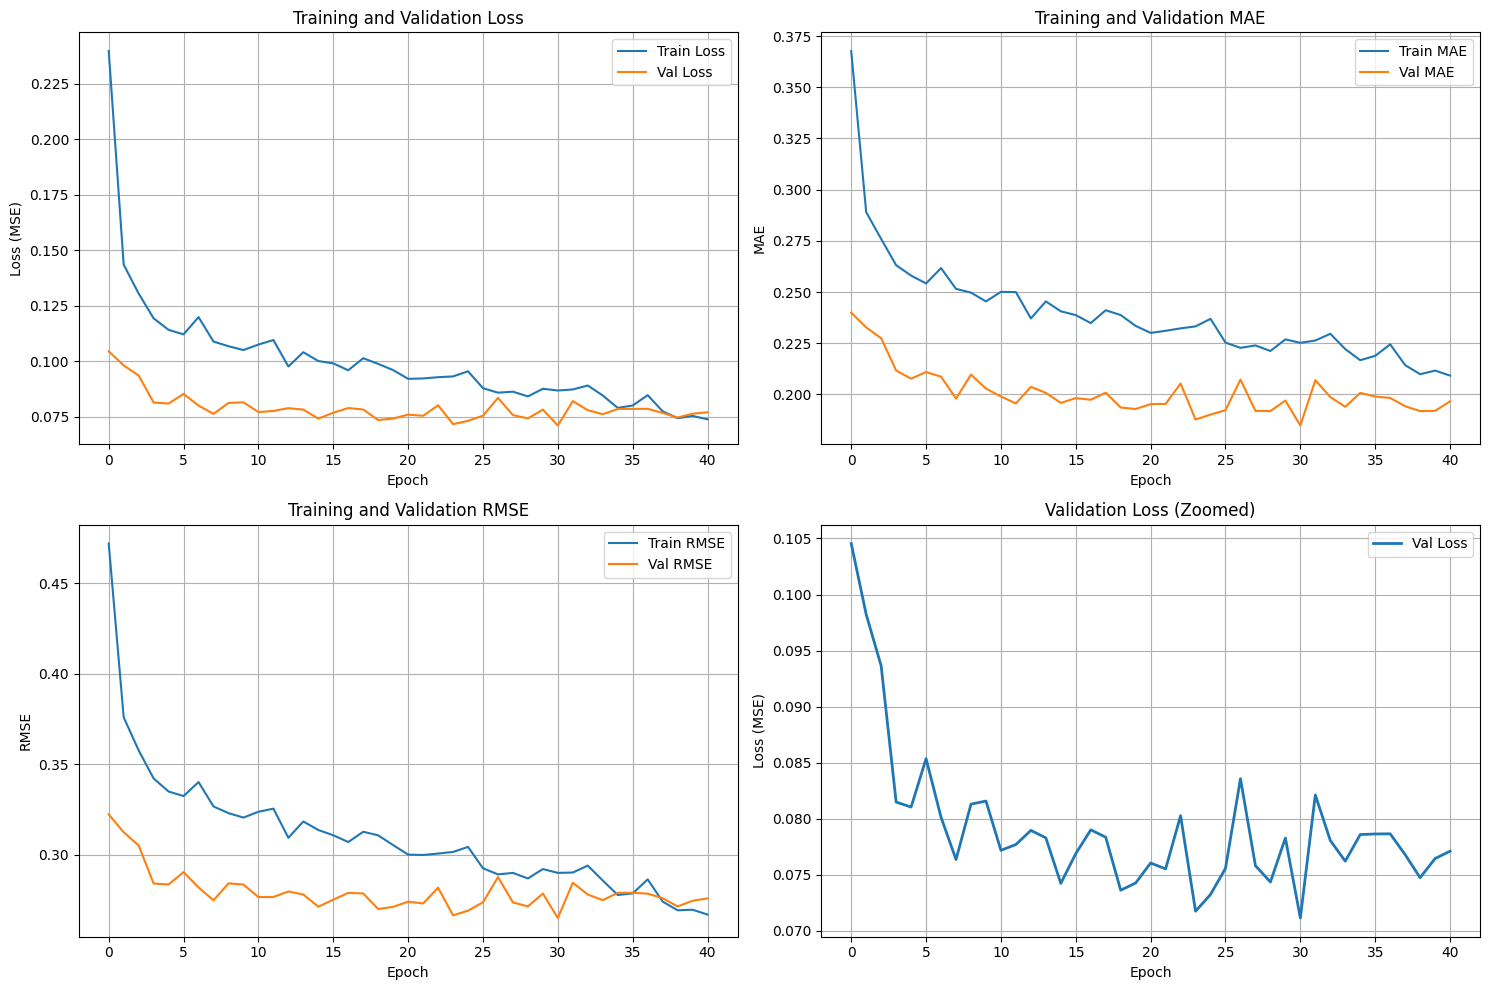


========== Predictions on Test Set ==========
Predictions shape: (358, 24)
Targets shape: (358, 24)


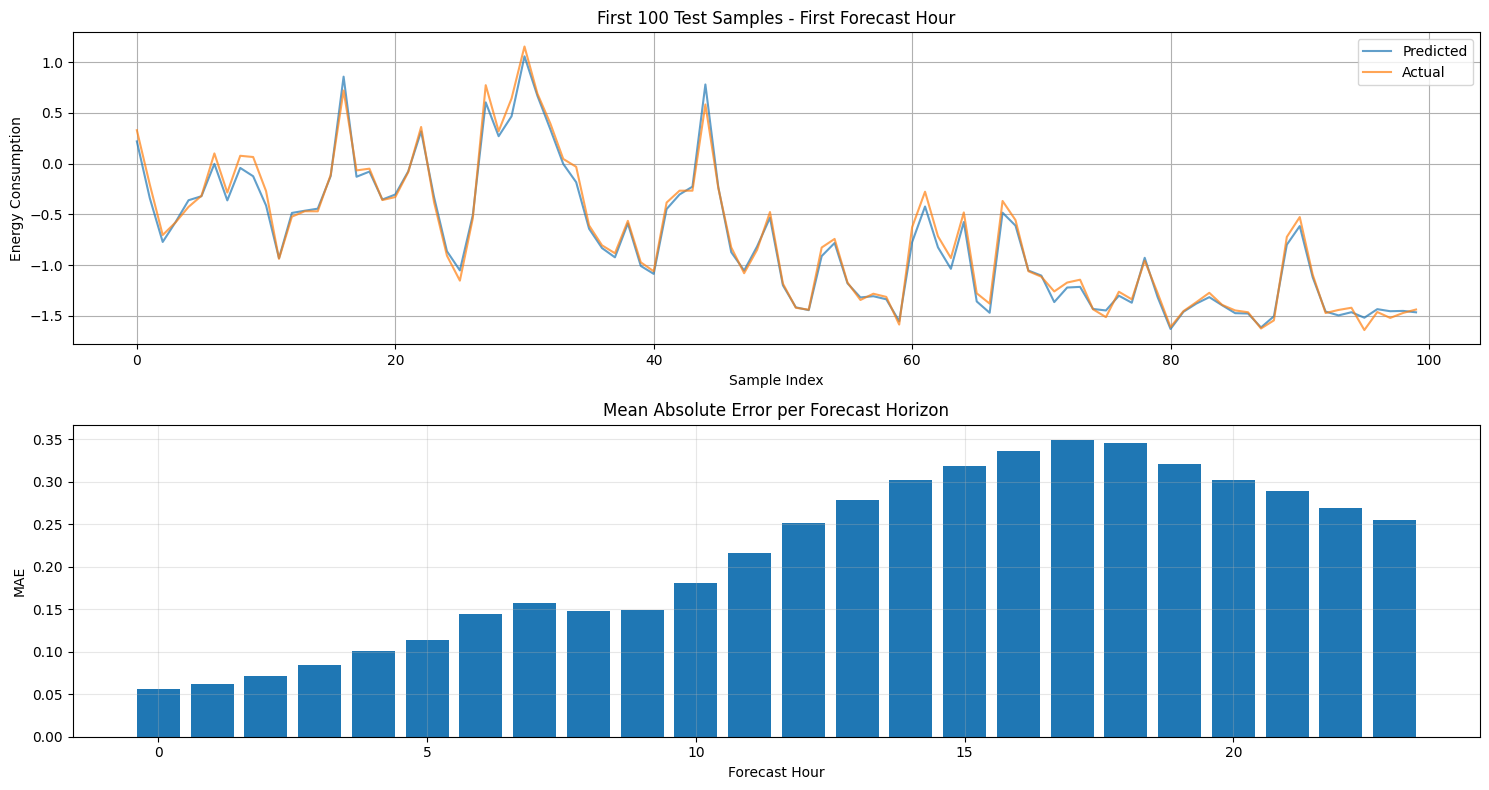

Figures saved to ../figures/


In [7]:
# ========== 訓練履歴の可視化 ==========
import os
fig, axes = trainer.plot_history(save_path="../figures/rnn_training_history.png")
plt.show()

# 予測結果の比較
print("\n========== Predictions on Test Set ==========")
all_predictions = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        predictions = model(x).cpu().numpy()
        all_predictions.append(predictions)
        all_targets.append(y.numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

print(f"Predictions shape: {all_predictions.shape}")
print(f"Targets shape: {all_targets.shape}")

# 最初の100サンプルの予測と実際値をプロット
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# 最初の予測値
axes[0].plot(all_predictions[:100, 0], label='Predicted', alpha=0.7)
axes[0].plot(all_targets[:100, 0], label='Actual', alpha=0.7)
axes[0].set_title('First 100 Test Samples - First Forecast Hour')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Energy Consumption')
axes[0].legend()
axes[0].grid(True)

# 平均予測誤差
mae_per_horizon = np.mean(np.abs(all_predictions - all_targets), axis=0)
axes[1].bar(range(len(mae_per_horizon)), mae_per_horizon)
axes[1].set_title('Mean Absolute Error per Forecast Horizon')
axes[1].set_xlabel('Forecast Hour')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/rnn_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figures saved to ../figures/")


In [9]:
all_predictions.shape

(358, 24)

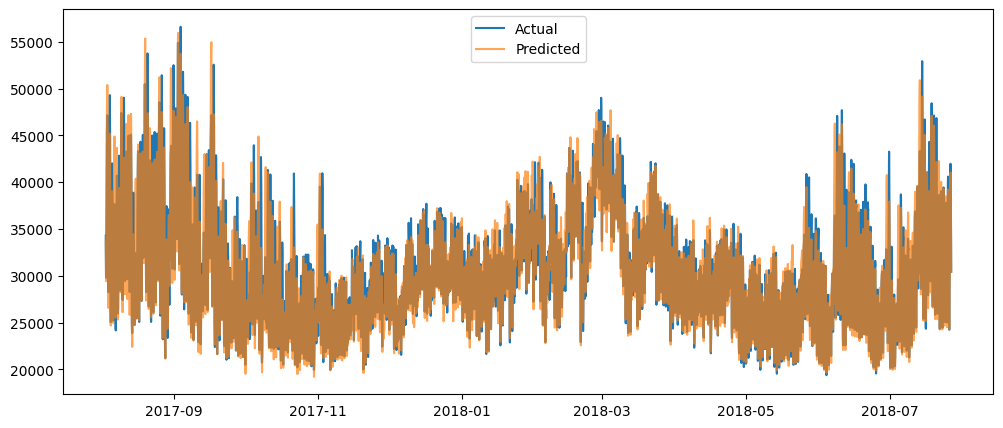

In [21]:
test_df = df.copy()
test_df["Datetime"] = pd.to_datetime(test_df["Datetime"])
test_df = test_df.sort_values("Datetime").reset_index(drop=True)
test_df = test_df[-365*24:]
plt.figure(figsize=(12, 5))
plt.plot(test_df["Datetime"][:len(all_targets.reshape(-1))], test_dataset.inverse_transform(all_targets.reshape(-1)), label='Actual')
plt.plot(test_df["Datetime"][:len(all_predictions.reshape(-1))], test_dataset.inverse_transform(all_predictions.reshape(-1)), label='Predicted', alpha=0.7)
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(test_dataset.inverse_transform(all_targets.reshape(-1)), test_dataset.inverse_transform(all_predictions.reshape(-1)))
rmse = root_mean_squared_error(test_dataset.inverse_transform(all_targets.reshape(-1)), test_dataset.inverse_transform(all_predictions.reshape(-1)))
mape = mean_absolute_percentage_error(test_dataset.inverse_transform(all_targets.reshape(-1)), test_dataset.inverse_transform(all_predictions.reshape(-1)))

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2%}")

MAE: 1381.94
RMSE: 2039.73
MAPE: 4.22%
